# Exercise 01 - DNN + Keras Tuner

## Group members:
Elena Niero; 2200437

Eylül Çağla Ersöz; 2185017

Melissa Daniela de Almeida Nespeque; 2183904

Sahasra Sivakumar; 2183897

### Instalation of libraries and data splitting


In [17]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Dropout
#add by me:
from keras import layers
from keras.callbacks import EarlyStopping
import keras.optimizers
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow.random as tf_r
import keras_tuner

# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py

# training/validation/test fractions
perc_train = 0.8
perc_valid = 0.10
perc_test = 0.10
#  check it sums to 1 
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

### Read all datasets - Normal: N=12000; Augmented data: N=12000 + noise; Reduced data: N=9000

(12000, 8)
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 0
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: 9600
valid: 1200
test: 1200


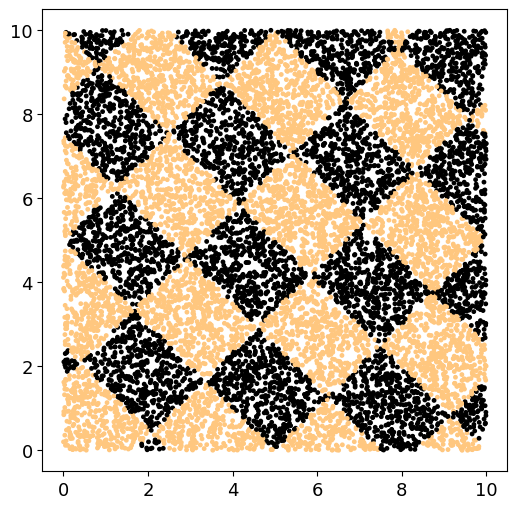

In [35]:
#Normal data
TYPE=4
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt('DATA/data-for-DNN_type4_L8.dat', delimiter=' ')
y = np.loadtxt('DATA/labels-for-DNN_type4_L8.dat', delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)

# dim. of a sample
#L = len(x[0])
#print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

plot_data(x,y)

(12000, 8)
data: 12000
train: 9600
valid: 1200
test: 1200


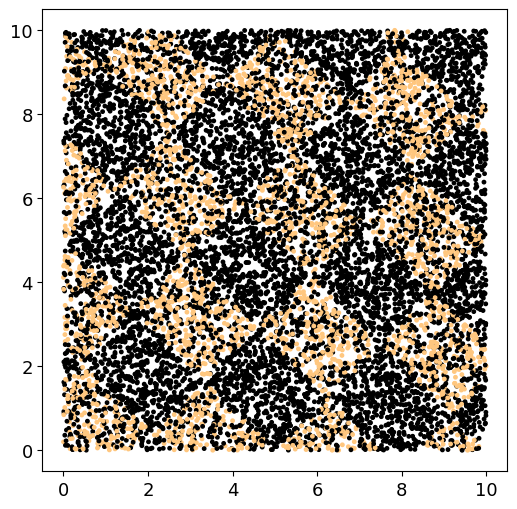

In [ ]:
#Augmented data
x_aug = np.loadtxt('DATA/data_aug0.05-for-DNN_type4_L8.dat', delimiter=' ')
y_aug = np.loadtxt('DATA/labels_aug0.05-for-DNN_type4_L8.dat', delimiter=' ')
y_aug = y_aug.astype("int")
print(x_aug.shape)
N_aug = len(x_aug)
# dim. of a sample
L = len(x_aug[0])
#print(L)

#for i in range(5):
 #   print(x_aug[i],y_aug[i])

N_train_aug = int(perc_train * N_aug)
N_valid_aug = int(perc_valid * N_aug)
N_test_aug = N_aug - N_train_aug - N_valid_aug
print(f'data: {N_aug}\ntrain: {N_train_aug}\nvalid: {N_valid_aug}\ntest: {N_test_aug}')

plot_data(x_aug,y_aug)

(9000, 8)
data: 9000
train: 7200
valid: 900
test: 900


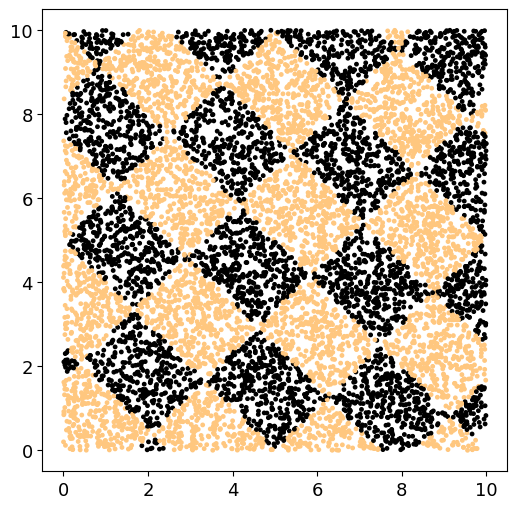

In [ ]:
#Reduced data
x_red = np.loadtxt('DATA/data-red-for-DNN_type4_L8.dat', delimiter=' ')
y_red = np.loadtxt('DATA/labels-red-for-DNN_type4_L8.dat', delimiter=' ')
y_red = y_red.astype("int")
print(x_red.shape)
N_red = len(x_red)
# dim. of a sample
L = len(x_red[0])
#print(L)

#for i in range(5):
 #   print(x_red[i],y_red[i])

N_train_red = int(perc_train * N_red)
N_valid_red = int(perc_valid * N_red)
N_test_red = N_red - N_train_red - N_valid_red
print(f'data: {N_red}\ntrain: {N_train_red}\nvalid: {N_valid_red}\ntest: {N_test_red}')

plot_data(x_red,y_red)

## Split data and standardize (fit on train only)

In [36]:
def Standardize(x,m,s):
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check 
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

x_all = np.concatenate((x_train, x_valid), axis = 0)
y_all = np.concatenate((y_train, y_valid), axis = 0)

Train: 9600 	 Validation: 1200 	 Test: 1200
after rescaling (train):
mean value= [ 2.03108363e-15  6.29479108e-15 -5.69839315e-15 -5.48011867e-15
 -4.38954428e-15 -3.07013674e-15 -4.04352477e-16 -1.01049493e-14] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


In [22]:
#Splitting augmented data
(x_train_aug, y_train_aug) = (x_aug[0:N_train_aug], y_aug[0:N_train_aug])
(x_valid_aug, y_valid_aug) = (x_aug[N_train_aug:N_train_aug+N_valid_aug], y_aug[N_train_aug:N_train_aug+N_valid_aug])
(x_test_aug, y_test_aug) = (x_aug[N_train_aug+N_valid_aug:],  y_aug[N_train_aug+N_valid_aug:])
#print("Train:",len(x_train_aug),"\t Validation:",len(x_valid_aug),"\t Test:",len(x_test_aug))

#mean and std:
x_train_mean_aug= np.mean(x_train_aug, axis=0)
x_train_std_aug = np.std(x_train_aug, axis=0)
x_valid_mean_aug = np.mean(x_valid_aug, axis=0)
x_valid_std_aug = np.std(x_valid_aug, axis=0)
x_test_mean_aug = np.mean(x_test_aug, axis=0)
x_test_std_aug = np.std(x_test_aug, axis=0)

#standardizing function
x_train_aug = Standardize(x_train_aug, x_train_mean_aug, x_train_std_aug)
x_valid_aug = Standardize(x_valid_aug, x_valid_mean_aug, x_valid_std_aug)
x_test_aug = Standardize(x_test_aug, x_test_mean_aug, x_test_std_aug)

#print("after rescaling (train):\nmean value=", x_train_aug.mean(axis=0), "\nstd. dev.=", x_train_aug.std(axis=0))

In [23]:
#Splitting reduced data
(x_train_red, y_train_red) = (x_red[0:N_train_red], y_red[0:N_train_red])
(x_valid_red, y_valid_red) = (x_red[N_train_red:N_train_red + N_valid_red], y_red[N_train_red:N_train_red + N_valid_red])
(x_test_red, y_test_red) = (x_red[N_train_red+N_valid_red:],  y_red[N_train_red+N_valid_red:])
#print("Train:",len(x_train_red),"\t Validation:",len(x_valid_red),"\t Test:",len(x_test_red))

#mean and std:
x_train_mean_red= np.mean(x_train_red, axis=0)
x_train_std_red = np.std(x_train_red, axis=0)
x_valid_mean_red = np.mean(x_valid_red, axis=0)
x_valid_std_red = np.std(x_valid_red, axis=0)
x_test_mean_red = np.mean(x_test_red, axis=0)
x_test_std_red = np.std(x_test_red, axis=0)

#standardizing function
x_train_red = Standardize(x_train_red, x_train_mean_red, x_train_std_red)
x_valid_red = Standardize(x_valid_red, x_valid_mean_red, x_valid_std_red)
x_test_aug = Standardize(x_test_aug, x_test_mean_red, x_test_std_red)

#print("after rescaling (train):\nmean value=", x_train_red.mean(axis=0), "\nstd. dev.=", x_train_red.std(axis=0))

## Define the model with Keras / Tensorflow

In [24]:
# reproducibility (?)
#np.random.seed(12345)
#tf_r.set_seed(12345)

# We use case 1
#CASE=1

#if CASE==1: # 4 layers
 #   model = Sequential()
  #  model.add(Dense(L,input_shape=(L,),activation='relu')) # first layer : L=8 neurons
   # model.add(Dense(20,activation='relu')) 
    #model.add(Dropout(0.1)) # rate for neuron dropout, in order to add noise we assign a probability that a neuron
    # and its connections are dropped out. It's like training a dynamic neural network, we have randoms.
#    model.add(Dense(20,activation='relu'))
 #   model.add(Dropout(0.1))
  #  model.add(Dense(20,activation='relu'))
   # model.add(Dropout(0.1))
    #model.add(Dense(1,activation='sigmoid'))
#    nepoch=200
# as case 1 but one layer shorter
#if CASE==2:
 #   model = Sequential()
  #  model.add(Dense(L,input_shape=(L,),activation='relu'))
   # model.add(Dense(40,activation='relu'))
    #model.add(Dropout(0.1)) 
#    model.add(Dense(20,activation='relu'))
 #   model.add(Dropout(0.1))
  #  model.add(Dense(1,activation='sigmoid'))
   # nepoch=200
#deeper
#if CASE==3: #deeper neural network
 #   model = Sequential()
  #  model.add(Dense(L,input_shape=(L,),activation='relu'))
   # model.add(Dense(10,activation='relu'))
    #model.add(Dense(10,activation='relu'))
#    model.add(Dense(10,activation='relu'))
 #   model.add(Dense(10,activation='relu'))
  #  model.add(Dense(10,activation='relu'))
   # model.add(Dense(10,activation='relu'))
    #model.add(Dense(1,activation='sigmoid'))
#    nepoch=200
    
#print(model.summary())

#how many parameters we have in our neural network?
# number of neurons, weigths and bias for each neuron, number of params = #input_units*#output_units + output_units
# case 1: 8*8+8 = 72
# we want to compare our num of params with the size of the dataset. We want num of total params < num of training sample otherwise 
# it's overfitting.

We build a function that allows us to explore the hyperparameter space using Keras:

In [25]:
#build function does not manually choose hyperparameters because it defines 
#the search space and the tuner picks the values during random search.
def build_model(hp):
    model = Sequential()
    
    activation = hp.Choice("activation", ["relu", "sigmoid", "elu"])
    dropout = hp.Choice("dropout", [0.0, 0.1, 0.2])
    
    model.add(Dense(L,input_shape=(L,),activation=activation))
    model.add(Dense(20,activation=activation)) 
    model.add(Dropout(dropout)) 
    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout))
    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout))
    model.add(Dense(1,activation="sigmoid"))
    
    lr = hp.Choice("learning_rate", [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1])
    optimizer_name = hp.Choice("optimizer", ["adam","rmsprop","sgd"])

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = keras.optimizers.SGD(learning_rate=lr, nesterov=True)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
build_model(keras_tuner.HyperParameters())

# we search the best hyperparameters at first in lot of trials (80)
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=80,
    #executions_per_trial=2,
    overwrite=True,
    directory="tuner_results",
    project_name="ex_1",
)

# we imlement early stopping
stop_early = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)


<Sequential name=sequential_2, built=True>

In [ ]:
# we search in 100 epochs for 80 trials
tuner.search(x_train, y_train, epochs=100, validation_data=(x_valid, y_valid), callbacks=[stop_early])


Trial 80 Complete [00h 00m 24s]
val_accuracy: 0.5066666603088379

Best val_accuracy So Far: 0.934166669845581
Total elapsed time: 00h 25m 47s


In [31]:
tuner.results_summary()


Results summary
Results in tuner_results/ex_1
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 36 summary
Hyperparameters:
activation: elu
dropout: 0.0
learning_rate: 0.01
optimizer: adam
Score: 0.934166669845581

Trial 01 summary
Hyperparameters:
activation: elu
dropout: 0.0
learning_rate: 0.01
optimizer: rmsprop
Score: 0.9041666388511658

Trial 23 summary
Hyperparameters:
activation: relu
dropout: 0.0
learning_rate: 0.1
optimizer: sgd
Score: 0.9008333086967468

Trial 11 summary
Hyperparameters:
activation: relu
dropout: 0.1
learning_rate: 0.001
optimizer: rmsprop
Score: 0.8383333086967468

Trial 29 summary
Hyperparameters:
activation: relu
dropout: 0.0
learning_rate: 0.01
optimizer: rmsprop
Score: 0.7925000190734863

Trial 15 summary
Hyperparameters:
activation: relu
dropout: 0.2
learning_rate: 0.001
optimizer: rmsprop
Score: 0.7666666507720947

Trial 30 summary
Hyperparameters:
activation: elu
dropout: 0.2
learning_rate: 0.01
optimizer: rmsprop
Score: 0.

In [ ]:
# Get the top 3 models.
models = tuner.get_best_models(num_models=3)
best_model = models[0]
best_model.summary()

/home/elena_niero/anaconda3/envs/nn_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/elena_niero/anaconda3/envs/nn_env/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/elena_niero/anaconda3/envs/nn_env/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,113 (4.35 KB)

 Trainable params: 1,113 (4.35 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#here we want to try the 3 best models in a cross validation set (we divide our dataset into 5 folds)
# in this way we can see which model has on average the best val_accuracy result
best_hps = tuner.get_best_hyperparameters(3)
results= {}

indices = np.arange(x_all.shape[0])
np.random.seed(123)
np.random.shuffle(indices)

x_all = x_all[indices]
y_all = y_all[indices]

k=5
fold_size = len(x_all)//k

for id, hp in enumerate(best_hps):
    print(f"\n Test hyperparameter model {id+1}")
    print(f"Learning rate: {hp.get('learning_rate')}, Optimizer: {hp.get('optimizer')}, Activation: {hp.get('activation')}")

    fold_accuracy = []
    
    for f in range(k):
        start, end = f*fold_size, (f+1)*fold_size
        x_val_f = x_all[start:end]
        y_val_f = y_all[start:end]
        x_train_f = np.concatenate([x_all[:start], x_all[end:]], axis = 0)
        y_train_f = np.concatenate([y_all[:start], y_all[end:]], axis = 0)
        
        model = build_model(hp)
        history = model.fit(x_train_f, y_train_f, epochs = 200, batch_size = 50, validation_data= (x_val_f, y_val_f)) #callbacks=[stop_early])
        fold_accuracy.append(history.history['val_accuracy'][-1])
        print(f"Fold {f+1} val_accuracy: {history.history['val_accuracy'][-1]}")
    
    results[f"Set_{id+1}"] = {
        "mean": np.mean(fold_accuracy),
        "std": np.std(fold_accuracy)
    }

for name, stats in results.items():
  print(f"{name}: Mean={stats['mean']:.4f}, Std={stats['std']:.4f}")




 Test hyperparameter model 1
Learning rate: 0.01, Optimizer: adam, Activation: elu
Epoch 1/200
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5075 - loss: 0.6946 - val_accuracy: 0.5148 - val_loss: 0.6923
Epoch 2/200
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5319 - loss: 0.6888 - val_accuracy: 0.5171 - val_loss: 0.6948
Epoch 3/200
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5315 - loss: 0.6899 - val_accuracy: 0.5185 - val_loss: 0.6904
Epoch 4/200
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5394 - loss: 0.6842 - val_accuracy: 0.5324 - val_loss: 0.6794
Epoch 5/200
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5396 - loss: 0.6820 - val_accuracy: 0.5343 - val_loss: 0.6772
Epoch 6/200
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5374 - loss: 0.6826 - val_accuracy: 0.5505 - val_loss: 0.6798
Epoch 7/200
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5407 - loss: 0.6806 - val_accuracy: 0.5690 - val_loss: 0.6748
Epoch 8/200
1

From the above results we can see that the best model is the first one with:

Hyperparameters:
activation: elu
dropout: 0.0
learning_rate: 0.01
optimizer: adam


In [ ]:
# Get the top 3 hyperparameters.
#best_hps = tuner.get_best_hyperparameters(3)
# Build the models with the best hp.
#We choose the best model and fit it in 200 epochs
model = build_model(best_hps[0])
# Fit with the entire dataset.
#x_all = np.concatenate((x_train, x_valid))
#y_all = np.concatenate((y_train, y_valid))
#fit = model.fit(x=x_all, y=y_all, epochs=200)
fit = model.fit(x_train, y_train, 
                epochs = 200, batch_size = 50, #size on which we are doing the gradients (batch_size= size of mini batches, the larger is batch size, the smoothest is our gradient, the smaller is the noisier is our gradient)
                validation_data=(x_valid,y_valid),
                verbose=2)

Epoch 1/200


/home/elena_niero/anaconda3/envs/nn_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


192/192 - 1s - 4ms/step - accuracy: 0.5082 - loss: 0.6969 - val_accuracy: 0.5158 - val_loss: 0.6913
Epoch 2/200
192/192 - 0s - 1ms/step - accuracy: 0.5115 - loss: 0.6927 - val_accuracy: 0.5275 - val_loss: 0.6907
Epoch 3/200
192/192 - 0s - 1ms/step - accuracy: 0.5210 - loss: 0.6916 - val_accuracy: 0.5025 - val_loss: 0.6968
Epoch 4/200
192/192 - 0s - 1ms/step - accuracy: 0.5160 - loss: 0.6904 - val_accuracy: 0.4983 - val_loss: 0.6902
Epoch 5/200
192/192 - 0s - 1ms/step - accuracy: 0.5177 - loss: 0.6877 - val_accuracy: 0.5250 - val_loss: 0.6967
Epoch 6/200
192/192 - 0s - 996us/step - accuracy: 0.5252 - loss: 0.6864 - val_accuracy: 0.5208 - val_loss: 0.6882
Epoch 7/200
192/192 - 0s - 986us/step - accuracy: 0.5250 - loss: 0.6844 - val_accuracy: 0.5250 - val_loss: 0.6858
Epoch 8/200
192/192 - 0s - 1ms/step - accuracy: 0.5274 - loss: 0.6849 - val_accuracy: 0.5292 - val_loss: 0.6855
Epoch 9/200
192/192 - 0s - 993us/step - accuracy: 0.5182 - loss: 0.6857 - val_accuracy: 0.5233 - val_loss: 0.683

## Optimization method and cost function

In [29]:
#now we have to define the cost function and the optimization method (we have binary classification => loss function is binary cross entropy)
#model.compile(loss='binary_crossentropy',
 #             optimizer='RMSprop',
              #optimizer='adam',
  #            metrics=['accuracy']) #metrics with wich our model is correct. Accuracy = # of predictions/# of total predictions
# = (TP+TN)/(TP+TN+FP+FN)

## Training

In [18]:
#fit = model.fit(x_train, y_train,
 #              epochs = nepoch, batch_size = 50, #size on which we are doing the gradients (batch_size= size of mini batches, the larger is batch size, the smoothest is our gradient, the smaller is the noisier is our gradient)
  #             validation_data=(x_valid,y_valid),
   #            verbose=2)
# for each epoch we print loss (binary cross entropy) and accuracy (numb of correct pred/tot pred)

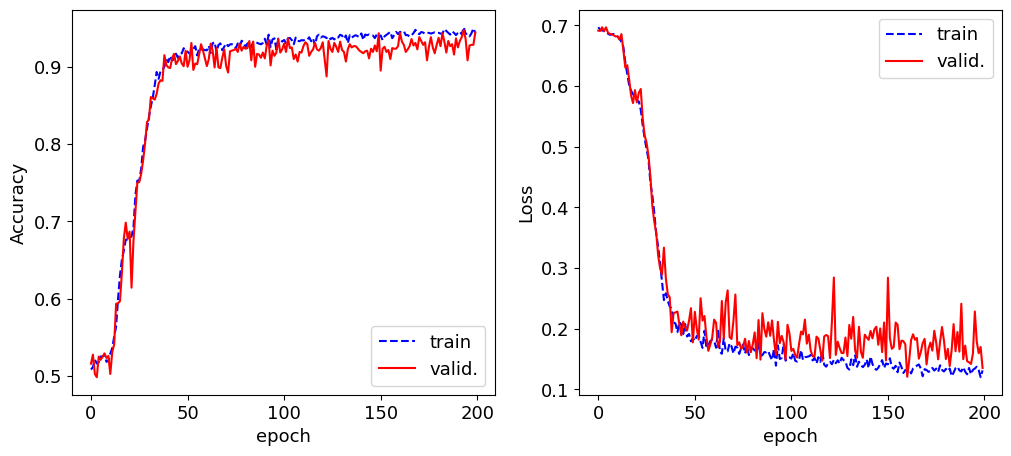

In [ ]:
#plot of train/val loss/accuracy for the best model
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

# we want the train and valid to go toghether (is what we aim for), the signature of overfitting ids the gap between train and valid loss,
# in the case of underfitting we see that the accuracy does not increases.
# when our loss is around 0.7 we have a random number generator, we always strart from 0.7! (make the count we the cross entropy formula)

# Evaluation on the test set


In [ ]:
# let's see how is the best model in the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.2214
Final test accuracy: 0.9150


## Grid to show preditions

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step


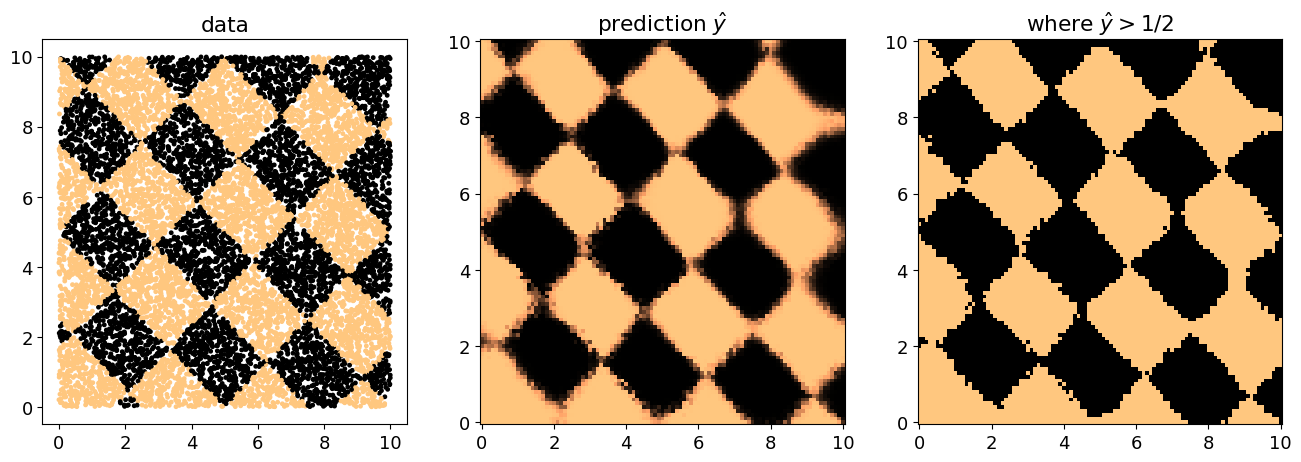

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [48]:
# we use neural network on a 10*10 grid, we create a colormap from 0 to 1 in fig 2 and a map we just 0 or 1 in fig 3
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")